In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import sin, cos, deg2rad,sqrt

In [29]:
# Experimental data
r = 7.44/100 # crank
l = 26.65/100 # connecting rod

theta = np.array([
    0,10,20,30,40,50,60,70,80,90,
    100,110,120,130,140,150,160,170,180,
    190,200,210,220,230,240,250,260,270,280,290,
    300,310,320,330,340,350,360
])

pos_cw = np.array([
    21.6,21.5,21.2,20.8,20.2,19.3,18.4,17.4,16.3,14.9,
    13.5,12.2,10.9,9.6,8.5,7.6,7.0,6.5,6.5,
    6.5,7.1,7.8,8.8,9.9,11.2,12.6,14.1,15.4,16.8,18.0,
    18.9,19.8,20.5,20.9,21.4,21.6,21.6
])/100

pos_acw = np.array([
    21.6,21.6,21.5,21.1,20.6,19.9,19.0,18.1,16.9,15.6,
    14.2,12.7,11.4,10.1,8.9,7.85,7.1,6.7,6.5,
    6.5,6.8,7.5,8.4,9.6,10.8,12.0,13.5,14.8,16.1,17.2,
    18.2,19.2,20.1,20.6,21.1,21.4,21.6
])/100

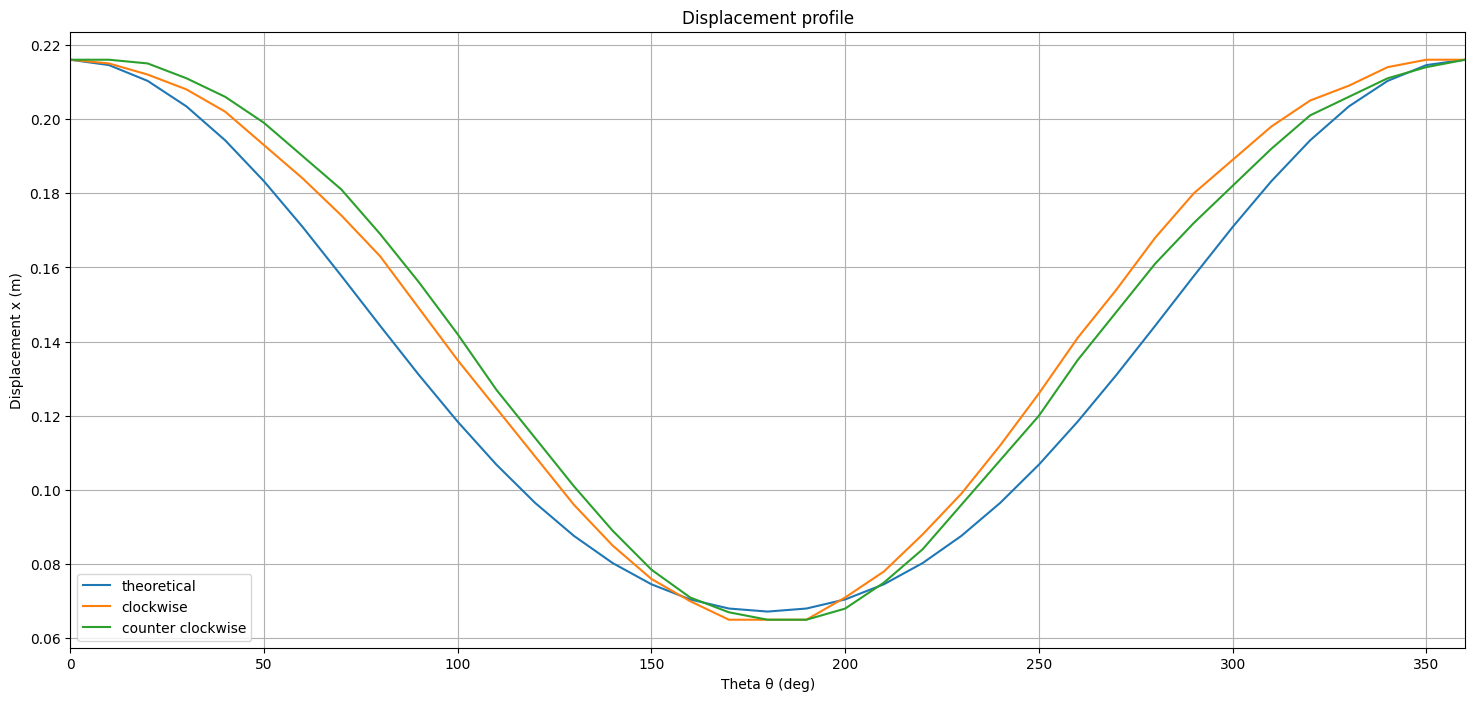

In [30]:
# Analysis
x = r * cos(deg2rad(theta)) + sqrt(l**2 - (r*sin(deg2rad(theta)))**2)

# changing the datum of x from crank's pivot to that used in the experiment
x -= x[0] - pos_cw[0]

plt.figure(figsize=(18, 8))
plt.plot(theta, x, label='theoretical')
plt.plot(theta, pos_cw, label='clockwise')
plt.plot(theta, pos_acw, label='counter clockwise')
plt.grid(True)
plt.xlabel("Theta θ (deg)")
plt.ylabel("Displacement x (m)")
plt.xlim(0,360)
plt.title("Displacement profile")
plt.legend()
plt.show()

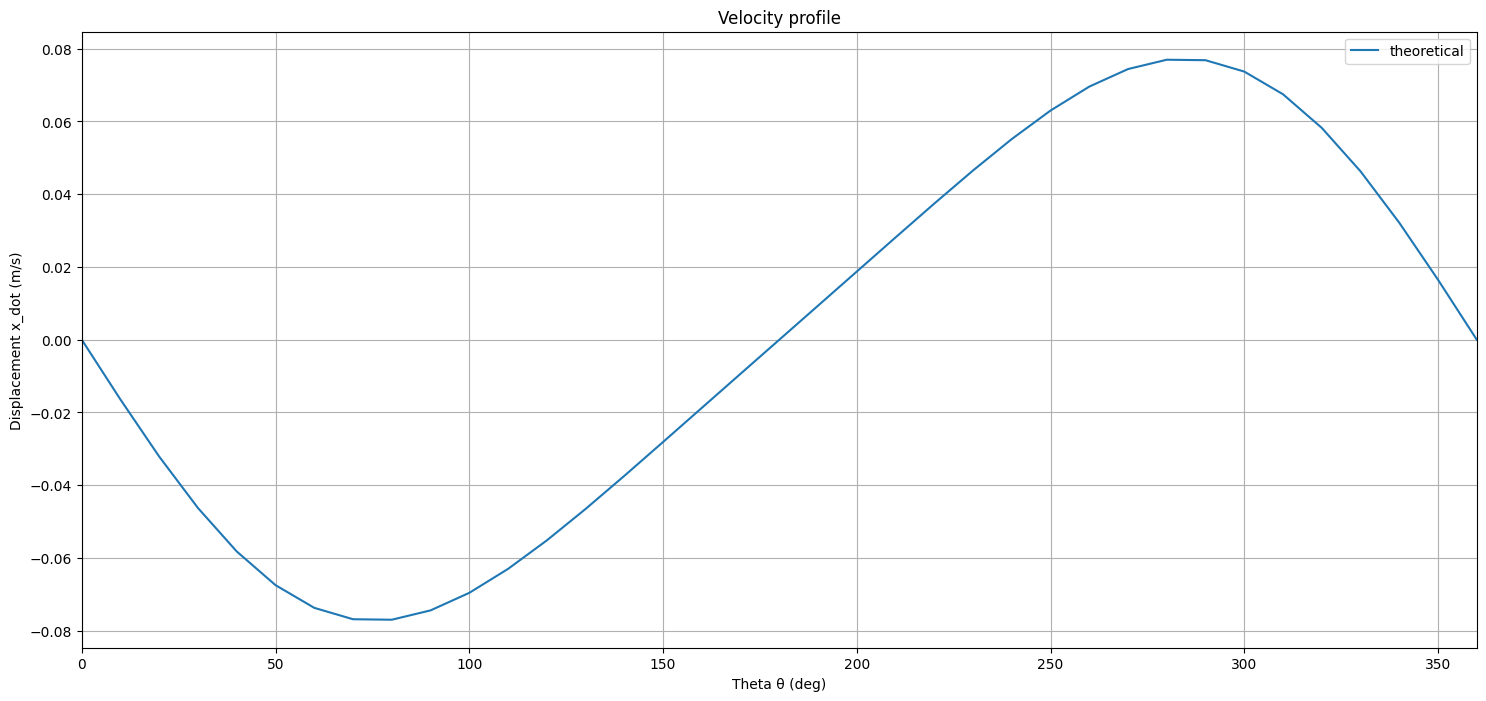

In [31]:
def v(theta, w):
  th = deg2rad(theta)
  a = r*sin(th)
  b_num = r**2*sin(th)*cos(th)
  b_den = sqrt(l**2-(r*sin(th))**2)
  return -(a+b_num/b_den)*w

w = 1 #rad/s (Assuming angular velocity)
v_theoretical = v(theta, w)

plt.figure(figsize=(18, 8))
plt.plot(theta, v_theoretical, label='theoretical')
plt.grid(True)
plt.xlabel("Theta θ (deg)")
plt.ylabel("Displacement x_dot (m/s)")
plt.xlim(0,360)
plt.title("Velocity profile")
plt.legend()
plt.show()

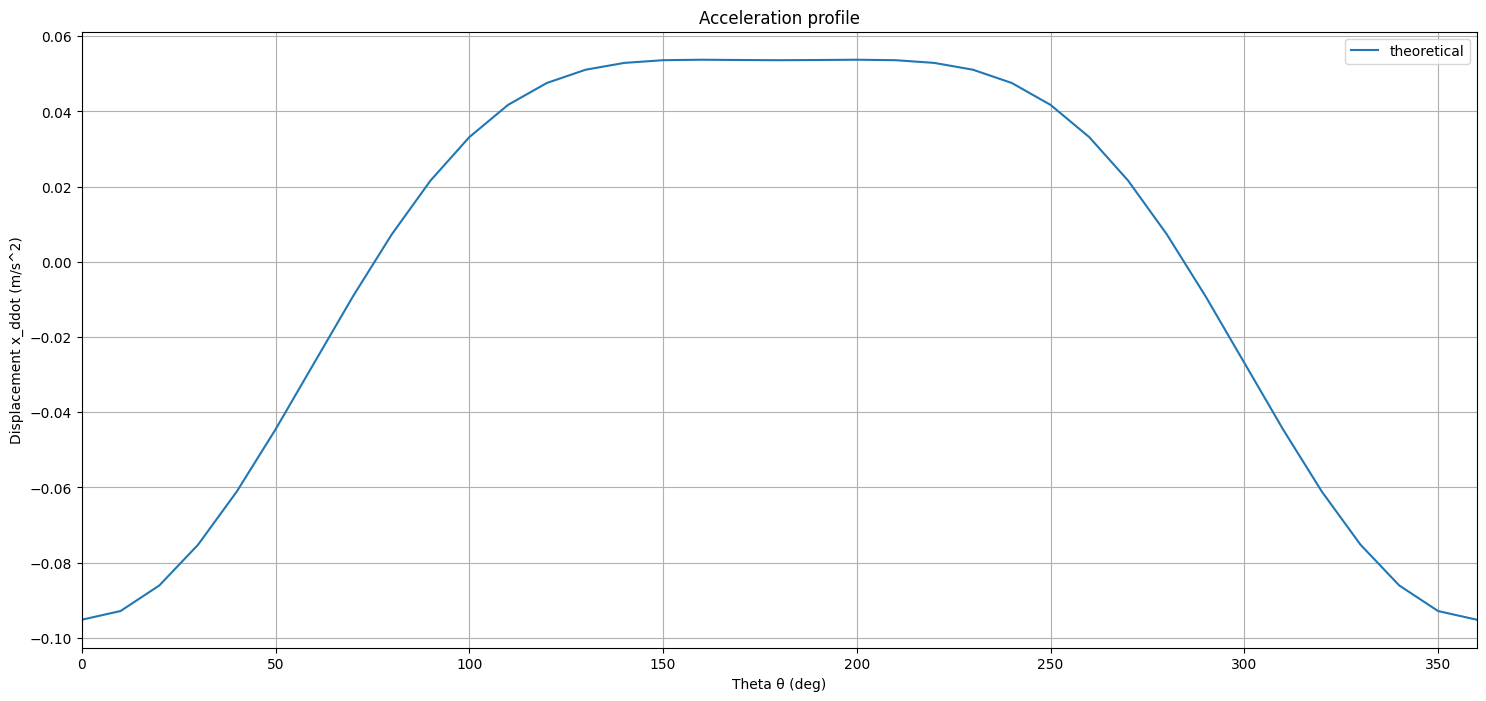

In [32]:
def a(theta, omega):
  s = sin(deg2rad(theta))
  c = cos(deg2rad(theta))

  g2 = l**2 - (r*s)**2
  g = sqrt(g2)

  a = -omega**2 * (
      r*c
      + (r**2 * (c**2 - s**2)) / g
      + (r**4 * s**2 * c**2) / (g2 * g)
  )

  return a

a_theoretical = a(theta, w)

plt.figure(figsize=(18, 8))
plt.plot(theta, a_theoretical, label='theoretical')
plt.grid(True)
plt.xlabel("Theta θ (deg)")
plt.ylabel("Displacement x_ddot (m/s^2)")
plt.xlim(0,360)
plt.title("Acceleration profile")
plt.legend()
plt.show()

In [37]:
data = pd.DataFrame({
    'theta':theta,
    'displacement_theoretical':x*100,
    'displacement_cw':pos_cw*100,
    'displacement_ccw':pos_acw*100,
    'error_cw': (x - pos_cw)*1000,
    'error_acw': (x - pos_acw)*1000
})
data.round(3)

,theta,displacement_theoretical,displacement_cw,displacement_ccw,error_cw,error_acw
0,0,21.600,21.6,21.60,0.000,0.000
1,10,21.456,21.5,21.60,-0.444,-1.444
2,20,21.030,21.2,21.50,-1.704,-4.704
3,30,20.342,20.8,21.10,-4.577,-7.577
4,40,19.427,20.2,20.60,-7.732,-11.732
5,50,18.326,19.3,19.90,-9.742,-15.742
6,60,17.089,18.4,19.00,-13.106,-19.106
7,70,15.771,17.4,18.10,-16.288,-23.288
8,80,14.425,16.3,16.90,-18.751,-24.751
9,90,13.100,14.9,15.60,-17.996,-24.996
